Generalised Profiling Tutorial<br>
Convergence Study

Alexander Johnston & James Bennett<br>
School of Mathematical Sciences, Queensland University of Technology<br>
ARC Centre of Excellence for the Mathematical Analysis of Cellular Systems<br>
a44.johnston@qut.edu.au / j39.bennett@qut.edu.au

- Normalised for dimensionless weights.
- Enforces model as `linear terms at update = nonlinear terms at last iteration'
- Toggle options:
  - set `use_LV_data' to 1 to use the Lotka--Volterra dataset appearing in the paper
  - BLARGH

In [46]:
#Load packages for calculations..
using DelimitedFiles, DifferentialEquations, SparseArrays, Random, Distributions, NLopt, BSplineKit, LinearAlgebra, OffsetArrays, LeastSquaresOptim
#...for housekeeping...
using IJuliaBell, ProgressMeter
#...and for graphics.
using LaTeXStrings, ColorSchemes, GLMakie
wongc = Makie.wong_colors();
GLMakie.activate!()
set_theme!(fonts = (; regular = "Computer Modern", bold = "Computer Modern Bold"),fontsize = 24)

Set `use_paper_dataset` to 1 to use data from Alex's paper. Otherwise, leave as zero to generate a new synthetic dataset.

In [47]:
#Toggle inputs.
use_paper_dataset = 1 #1 means use the dataset from the paper, 0 means generate a new synthetic dataset
use_new_norm = 0; #1 means use the maximally linear normalisation.
use_natural_splines = 1; #1 means use cardinal b-splines with natural boundary conditions for the initial unregularised fit.

In [150]:
if use_paper_dataset == 1
    #DO NOT ALTER THIS PART OF THE 'IF' BLOCK.
    
    #Model parameters

    r1 = 100;
    r2 = 100;
    K1 = 210;
    K2 = 210;
    c1_0 = 1000;
    c2_0 = 400;
    
    a = [r1, r2, K1, K2];
    
    #Initial conditions
    x0 = c1_0;
    y0 = c2_0;

    #Number of synthetic data points (each)
    N_data = 41;

    #Ratio of number of points in the spline grid to the number of points in the synthetic data set 
    grid_ratio = 10;

    #Discretisation grid size for spline
    N_t = grid_ratio*(N_data - 1)+1;

    #Time domain over which to create synthetic data.
    t_start = 0; t_end = 25;
    t_true = LinRange(t_start, t_end, N_t);

    #Standard deviation of additive Gaussian noise used to generate the synthetic data
    sigma = 5 ;

    a_test = [80, 80, 160, 160]

    t_data = readdlm("t_synthetic_data_Michaelis-Menten reduced noise 2", '\t', Float64, '\n')[:]
    x_data = readdlm("c1_synthetic_data_sample_Michaelis-Menten reduced noise 2", '\t', Float64, '\n')[:]
    y_data = readdlm("c2_synthetic_data_sample_Michaelis-Menten reduced noise 2", '\t', Float64, '\n')[:]
else

    r1 = 100;
    r2 = 100;
    K1 = 210;
    K2 = 210;
    c1_0 = 1000;
    c2_0 = 400;
    
    a = [r1, r2, K1, K2];
    
    #Initial conditions
    x0 = c1_0;
    y0 = c2_0;

    #Number of synthetic data points (each)
    N_data = 41;

    #Ratio of number of points in the spline grid to the number of points in the synthetic data set 
    grid_ratio = 10;

    #Discretisation grid size for spline
    N_t = grid_ratio*(N_data - 1)+1;

    #Time domain over which to create synthetic data.
    t_start = 0; t_end = 25;
    t_true = LinRange(t_start, t_end, N_t);
    tt = t_true;

    #Standard deviation of additive Gaussian noise used to generate the synthetic data
    sigma = 5 ;
    
    #Create synthetic data for the Michaelis-Menten model.
    
    #Michaelis-Menten equations
    function Michaelis_Menten!(du,u,a,t)
        r1 = a[1];
        r2 = a[2];
        K1 = a[3];
        K2 = a[4];
        du[1]=-r1*u[1]/(K1 .+ u[1]);
        du[2]=r1*u[1]/(K1 .+ u[1]) - r2*u[2]/(K2 .+ u[2]);
    end
    
    function odesolver(t,ic,a)
        tspan=(0.0,maximum(t))
        prob=ODEProblem(Michaelis_Menten!,ic,tspan, a)
        alg=Tsit5()
        sol=solve(prob,alg,saveat=t);
        return sol
    end
    
    sol = odesolver(tt,ic,a)
       
    x = sol[1,:];
    y = sol[2,:];

    a_test = [90, 90, 190, 190]

    function noise_model(t,x,y,sigma,grid_ratio)
        #Make a sub-sampled t grid and observations.
        t_sub = [];
        x_sub = [];
        y_sub = [];
        for i ∈ eachindex(t_true)
            if (i-1)%grid_ratio == 0
                push!(t_sub, t[i])
                push!(x_sub, x[i])
                push!(y_sub, y[i])
            end
        end
        #Create stochastic data using additive Gaussian noise applied at each data point for the true solution
        dist=Normal(0,sigma);
        x_data = x_sub + rand(dist,size(x_sub))
        y_data = y_sub + rand(dist,size(y_sub))
        return (t_sub,x_data,y_data)
    end

    (x_true,y_true) = odesolver(t_true,ic,a);
    (t_data,x_data,y_data) = noise_model(t_true,x_true,y_true,sigma,grid_ratio);
end

#Set bounds on allowable parameters in numerical solver.
lb=[10, 10, 100, 100]
ub=[150, 150, 300, 300];

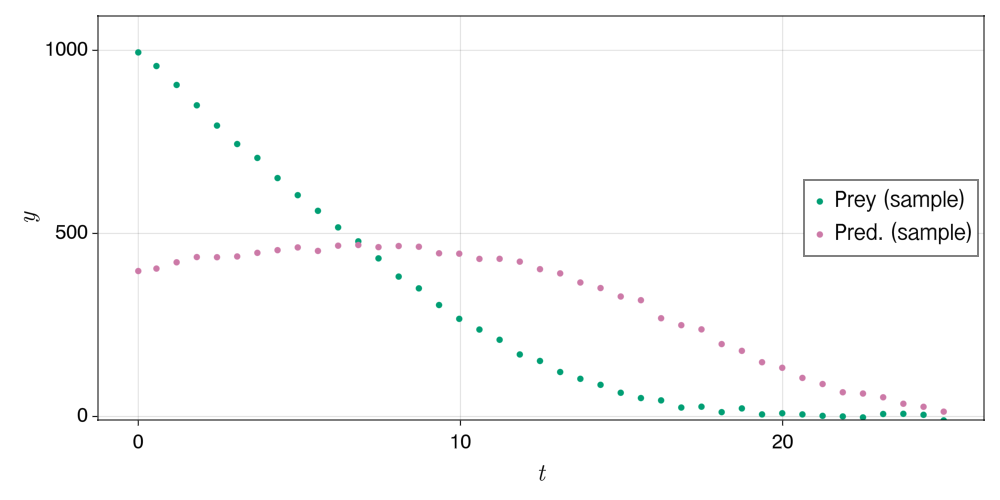

In [151]:
#Plot the synthetic data.
fig = Figure(size = (1000, 500))
let ax = Axis(fig[1,1], xlabel = L"t", ylabel = L"y")
    if use_paper_dataset ≠ 1
        lines!(t_true,x_true,color=wongc[3],label="Prey (true)")
        lines!(t_true,y_true,color=wongc[4],label="Pred. (true)")
    end
    scatter!(t_data,x_data,color=wongc[3],label="Prey (sample)")
    scatter!(t_data,y_data,color=wongc[4],label="Pred. (sample)")
    ylims!(0.9*minimum([x_data y_data]),1.1*maximum([x_data y_data]))
    axislegend(ax, position = :rc)
end
fig

In [152]:
#Relabel some variables for use later.
#This is to make it easier to reuse the code with real data instead of synthetic data.
t_fit = copy(t_true); #We're going to construct a B-spline basis on this grid.

We're going to construct our fit in two stages.

Firstly, we use a natural cardinal b-spline expansion of order 4 (cubic b-splines `Bnat` with equally spaced interior knots and no curvature at the boundaries). We then forms matrices of sampled b-splines evaluated at the locations of each observation (`Bnat_obs_x` and `Bnat_obs_y`). These are used for the _unregularised_ fit, to assist in suppressing large-amplitude oscillations caused by strong overfitting at this step.

We then approximate our initial fit using a cardinal b-spline basis with no boundary conditions imposed, `B`. This has corresponding observation matrices `B_obs_x` and `B_obs_y`, which are used throughout the regularisation. Since we are regularising based on the L-V model (1st-order coupled ODEs), we also require the first derivatives of our splines (`D1B`).

In [153]:
#Construct a (cardinal) b-spline basis. Uncomment the code at the bottom of the cell to plot your basis functions.
#Natural cardinal b-splines basis for the unregularised fit.
Bnat = BSplineKit.BSplineBasis( BSplineKit.BSplineOrder(4), LinRange(t_start, t_end, N_data))
Bnat = RecombinedBSplineBasis(Bnat, Natural())
#Cardinal basis for later fits (no boundary conditions imposed).
B = BSplineKit.BSplineBasis( BSplineKit.BSplineOrder(4), LinRange(t_start, t_end, N_data-2))

41-element BSplineBasis of order 4, domain [0.0, 25.0]
 knots: [0.0, 0.0, 0.0, 0.0, 0.657895, 1.31579, 1.97368, 2.63158, 3.28947, 3.94737  …  21.0526, 21.7105, 22.3684, 23.0263, 23.6842, 24.3421, 25.0, 25.0, 25.0, 25.0]

In [154]:
#Construct a B-Spline matrix for each basis
Bnat_matrix = collocation_matrix(Bnat, t_fit, BSplineKit.Derivative(0), SparseMatrixCSC{Float64})
B_matrix = collocation_matrix(B, t_fit, BSplineKit.Derivative(0), SparseMatrixCSC{Float64})
#Construct matrix of derivatives of basis elements (not required for the natural basis, since we're not regularising with it)
D1B = collocation_matrix(B, t_fit, BSplineKit.Derivative(1), SparseMatrixCSC{Float64});

#Construct a vector of indices, i_obs, showing the indices of the fine grid of true data, t_data,
#that correspond to values of the synthetic data subset, t
i_obs_x = []
i_obs_y = []
dtfine = t_true[2]-t_true[1]
for (i, t_i) ∈ enumerate(t_fit)
    # if t_i in t_data
    for j ∈ axes(t_data,1)
        if isapprox(t_i,t_data[j],atol = dtfine/2 ) == 1
            append!(i_obs_x,i)
            append!(i_obs_y,i)
        end
    end
end

#Construct an A_obs matrix. Each row of this matrix consists of 0s and a single 1.
#The location of the 1 is specificed by the index of the i_obs vector.

function create_A_obs(i_obs)
    A_obs = zeros(Int, length(i_obs), length(t_fit))
    for i ∈ range(1, length(i_obs))
        A_obs[i, i_obs[i]] = 1
    end
    return A_obs
end

#Construct A_obs, B_obs.
A_obs_x = create_A_obs(i_obs_x);
A_obs_y = create_A_obs(i_obs_y);
Bnat_obs_x = A_obs_x*Bnat_matrix;
Bnat_obs_y = A_obs_y*Bnat_matrix;
B_obs_x = A_obs_x*B_matrix;
B_obs_y = A_obs_y*B_matrix;

Δt = t_data[2]-t_data[1]

0.5639097744360901

In [155]:
#This is the expected variance scale for the first derivative of uncorrelated data.
function normalisation_std_calc(sigma,Δtin,θin)
    s = sqrt(2)*sigma/Δtin
    if use_new_norm == 1
        s = s * sqrt(1. + (θin[1]+1.)*Δtin + 0.5*(θin[1]^2+1. )*Δtin^2 )
    end
    return s
end

normalisation_std_calc (generic function with 1 method)

In [156]:
function model_ode_RHS(xin,yin,θin)
#Calculates RHS of ODE model used to regularise.
    f = [  -θin[1]*xin./(θin[3] .+ xin) ; θin[1]*xin./(θin[3] .+ xin) .- θin[2]*yin./(θin[4] .+ yin) ]
    return f
end

function weighted_loglikelihood(w,x_data,y_data,betas_x,betas_y,θin,sigma)
#Calculate the penalised log-likelihood function for a given set of parameters and coefficients.
    g = vcat(B_obs_x*betas_x, B_obs_y*betas_y);
    y1 = vcat(x_data, y_data);
    dist = Normal(0,sigma);
    if use_new_norm == 1
        y2= [ D1B*betas_x - θin[1]*B_matrix*betas_x;
              D1B*betas_y + B_matrix*betas_y];
    else
        y2= [D1B*betas_x; D1B*betas_y];
    end
    f = model_ode_RHS(B_matrix*betas_x, B_matrix*betas_y, θin)
    sigma_D = normalisation_std_calc(sigma,Δt,θin)
    ℒ = loglikelihood(dist, (y1.-g)) - norm( y2-f )^2 / sigma_D^2; 
    return ℒ
end

#Optimises the input function fun over the input parameters θ₀ (use for maximising the penalised log-likelihood).
function Optimise(fun,θ₀,lb,ub,w)
    tomax=(θ,∂θ)->fun(θ)
    opt=Opt(:LN_NELDERMEAD,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=60 #One minute max runtime per optimisation.
    res = NLopt.optimize(opt,θ₀)
    return res[[2,1]];
end

#New values of w are based on standard deviations of results from previous step

function standard_deviation_data_norms(x_data,y_data,betas_x,betas_y)
    g = vcat(B_obs_x*betas_x, B_obs_y*betas_y);
    y = vcat(x_data, y_data);
    e = std((y.-g));
    return e
end;

function standard_deviation_model_norms(betas_x,betas_y,θin)
    f = model_ode_RHS(B_matrix*betas_x, B_matrix*betas_y, θin)
    if use_new_norm == 1
        y2= [ D1B*betas_x - θin[1]*B_matrix*betas_x;
              D1B*betas_y + B_matrix*betas_y];
    else
        y2= [D1B*betas_x; D1B*betas_y];
    end
    e = std( y2-f );
    return e
end;

#Alex's nonlinear least-squares wrapper.
function NLLS_function(A, b)
    function matrix_equation(x)
        A*x - b
    end
    x0 = ones(length(A[1,:]))
    result = LeastSquaresOptim.optimize(matrix_equation, x0, LeastSquaresOptim.Dogleg())
    return result.minimizer
end

NLLS_function (generic function with 1 method)

<img src="scheme.png" style="width:600px">

In [157]:
#Unregularised fit to the splines using the natural cardinal b-splines.
# betasnat_x_in = Bnat_obs_x \ x_data; #Fit to natural cardinal b-splines
# betasnat_y_in = Bnat_obs_y \ y_data;

betasnat_x_in = NLLS_function(Bnat_obs_x, x_data)
betasnat_y_in = NLLS_function(Bnat_obs_y, y_data)

#Helper function to assist converting from Bnat to B.
function unregfitfun(xin,betasnat)
    pr = zeros(length(betasnat))
    for j ∈ eachindex(pr)
        pr[j] = betasnat[j]*Bnat[j](xin)
    end
    return sum(pr)
end 

#Now translate the unregularised fit into the cardinal basis.
betas_x_in = coefficients( approximate(x->unregfitfun(x,betasnat_x_in), B, MinimiseL2Error()) )
betas_y_in = coefficients( approximate(x->unregfitfun(x,betasnat_y_in), B, MinimiseL2Error()) )

function regularise(win,θG,betas_x_in,betas_y_in,qmax)
    
    #Open memspace for storing data as we iterate the regularisation.
    βxsave = zeros(length(betas_x_in),qmax+1) #Fit coefficients.
    βysave = zeros(length(betas_y_in),qmax+1)
    θsave = zeros(length(θG),qmax+1) #Parameters.
    wsave = zeros(qmax) #Weights.
    varsave = zeros(2,qmax+1) #Variances of data and model residuals.
    sigma_Dsave = zeros(qmax) #Estimated derivative std based on model.
    #Offset indices where appropriate.
    βxsave = OffsetArrays.Origin(1,0)(βxsave)
    βysave = OffsetArrays.Origin(1,0)(βysave)
    θsave = OffsetArrays.Origin(1,0)(θsave)
    varsave = OffsetArrays.Origin(1,0)(varsave)
    #Populate with estimates from loop 0.
    βxsave[:,0] = betas_x_in
    βysave[:,0] = betas_y_in
    θsave[:,0] = θG
    varsave[1,0] = ( standard_deviation_data_norms(x_data, y_data, betas_x_in, betas_y_in) )^2
    varsave[2,0] = ( standard_deviation_model_norms(betas_x_in, betas_y_in, θG) )^2

    for q ∈ 1:qmax
        #Forecast our expected model std.
        sigma_Dsave[q] = normalisation_std_calc(sigma,Δt,θsave[:,q-1])
        
        #Update weight.
        if q == 1 #Stipulate the first weight to try.
            wsave[1] = win
        else #Update based on rule.
            wsave[q] = ( varsave[1,q-1]/varsave[2,q-1] )^0.5 * sigma_Dsave[q]/sigma * (2*N_data-1)/(2*length(t_true)-1)
        end
        
        #Calculate updated fit coefficients, β.
        #We're doing this as a linear thing, which I guess is fine for Gaussian additive noise..?
        f = model_ode_RHS(B_matrix*βxsave[:,q-1], B_matrix*βysave[:,q-1], θsave[:,q-1])
        if use_new_norm == 1
            x_data_aug =  vcat(x_data./sigma,  wsave[q]*f[1:size(B_matrix,1)]./sigma_Dsave[q]);
            y_data_aug =  vcat(y_data./sigma,  wsave[q]*f[size(B_matrix,1)+1:end]./sigma_Dsave[q]);
            # betas_x_reg = vcat(B_obs_x./sigma, wsave[q]*(D1B - θsave[1,q-1]*B_matrix)./sigma_Dsave[q]) \ x_data_aug;
            # betas_y_reg = vcat(B_obs_y./sigma, wsave[q]*(D1B + B_matrix)./sigma_Dsave[q]) \ y_data_aug;
            betas_x_reg = NLLS_function( vcat(B_obs_x./sigma, wsave[q]*(D1B - θsave[1,q-1]*B_matrix)./sigma_Dsave[q]) , x_data_aug)
            betas_y_reg = NLLS_function( vcat(B_obs_y./sigma, wsave[q]*(D1B + B_matrix)./sigma_Dsave[q]) , y_data_aug)
        else
            x_data_aug =  vcat(x_data./sigma,  wsave[q]*f[1:size(B_matrix,1)]./sigma_Dsave[q]);
            y_data_aug =  vcat(y_data./sigma,  wsave[q]*f[size(B_matrix,1)+1:end]./sigma_Dsave[q]);
            # betas_x_reg = vcat(B_obs_x./sigma, wsave[q]*D1B./sigma_Dsave[q]) \ x_data_aug;
            # betas_y_reg = vcat(B_obs_y./sigma, wsave[q]*D1B./sigma_Dsave[q]) \ y_data_aug;
            betas_x_reg = NLLS_function( vcat(B_obs_x./sigma, wsave[q]*D1B./sigma_Dsave[q]) , x_data_aug)
            betas_y_reg = NLLS_function( vcat(B_obs_y./sigma, wsave[q]*D1B./sigma_Dsave[q]) , y_data_aug)
        end

        #Now update MLE function based on updated β fits.
        function funmle_reg(θin)
            return weighted_loglikelihood(wsave[q],x_data,y_data,betas_x_reg,betas_y_reg,θin,sigma);
        end
        
        #Recalculating the MLE parameters.
        (θMLE,ℒMLE) = Optimise(funmle_reg,θsave[:,q-1],lb,ub,wsave[q]) #Feed in the previous MLE as an initial guess.

        #Save.
        θsave[:,q] = θMLE
        βxsave[:,q] = betas_x_reg
        βysave[:,q] = betas_y_reg
        varsave[1,q] = ( standard_deviation_data_norms(x_data, y_data, betas_x_reg, betas_y_reg) )^2
        varsave[2,q] = ( standard_deviation_model_norms(betas_x_reg, betas_y_reg, θMLE) )^2
    end
    return (θsave,varsave,wsave,βxsave,βysave,sigma_Dsave)
end

regularise (generic function with 1 method)

Let's compare to terminating by investigating minimisation of the model variance. This requires us to determine whether we've reached a minimum. We want to be insensitive to small local minima.

We proceed as follows;
- ingest the variances of all $q$ iterations completed thus far
- fit a quadratic to these data. Determine the index $q_{\text{min}}^{(q)}$ of the minumum of the quadratic (do not round at this stage).
- if $\left|q_{\text{min}}^{(q)}-q_{\text{min}}^{(q-1)}\right|$ drops belows a threshold value, terminate.
- The minimum is taken to be at index $q_{\text{min}}^{(q)}$ rounded to the nearest integer.

In [205]:
#Now let's loop over different starting weights and see what we can find.
qmax = 60
n_scan = 100
w₁scan = LinRange(-2,2,n_scan)
w₁scan = 10. .^(w₁scan)

q_mvcl = zeros(n_scan) #model variance convergence loop counter
q_pcl = zeros(n_scan) #parameter convergence loop counter
θ_mvcl = zeros(length(a_test),n_scan)
θ_pcl = zeros(length(a_test),n_scan)
#Dump intermediate results to memory as we go.
θmid = zeros(length(a_test),qmax+1,n_scan)
varmid = zeros(2,qmax+1,n_scan)
wmid = zeros(1,qmax,n_scan)
sigma_Dmid = zeros(1,qmax,n_scan)
βmid = zeros(length([betas_x_in; betas_y_in]),qmax+1,n_scan)
#Offset as appropriate.
θmid = OffsetArrays.Origin(1,0,1)(θmid)
varmid = OffsetArrays.Origin(1,0,1)(varmid)
βmid = OffsetArrays.Origin(1,0,1)(βmid)

@showprogress for j ∈ 1:n_scan
    (θmid[:,:,j],varmid[:,:,j],wmid[:,:,j],βmid[1:length(betas_x_in),:,j],βmid[length(betas_x_in)+1:end,:,j],sigma_Dmid[:,:,j]) =
        regularise(w₁scan[j],a_test,betas_x_in,betas_y_in,qmax)
end
#@bell display("Complete.")

Progress: 100%|█████████████████████████████████████████| Time: 0:01:30


In [206]:
colorscheme = :ocean
set_theme!(fonts = (; regular = "CMUSerif-Math", bold = "CMUSerif-Math"),fontsize = 24)

fig = Figure(size=(1200,800))

let ax = Axis(fig[1,1:2], xlabel=L"n", ylabel=L"\log_{10} \left( w^{(n)} \right)", xticks=([0, 20, 40, 60],[L"0", L"20", L"40", L"60"]), yticks=([-2, 0, 2],[L"-2", L"0", L"2"]), xlabelsize = 25, ylabelsize = 25, limits = ((0, qmax), nothing))
    ttp = log10.(wmid)
    sz = size(wmid,3)
    cin = Int.( ceil.( 100* LinRange(1,sz,sz)./sz) )
    for j ∈ axes(ttp,3)
        j = n_scan + 1 - j
        scatterlines!(ttp[1,:,j],color = colorschemes[colorscheme].colors[cin[j]])
    end
    
end
let ax = Axis(fig[2,1], ylabel=L"$r_1$", xticks=([0, 20, 40, 60],[L"0", L"20", L"40", L"60"]), yticks=([80, 90, 100],[L"80", L"90", L"100"]), limits = ((0, qmax), nothing), xlabelsize = 25, ylabelsize = 25)

    ttp = θmid[1,:,:]
    sz = size(ttp,2)
    cin = Int.( ceil.( 100* LinRange(1,sz,sz)./sz) )
    
    for j ∈ axes(ttp,2)
        j = n_scan + 1 - j
        scatterlines!(ttp[:,j],color = colorschemes[colorscheme].colors[cin[j]])
    end
    lines!([-1.; qmax+1.], a[1]*[1.; 1.],color=:red)
end
let ax = Axis(fig[2,2], ylabel=L"$r_2$", xticks=([0, 20, 40, 60],[L"0", L"20", L"40", L"60"]), yticks=([80, 90, 100, 110],[L"80", L"90", L"100", L"110"]), limits = ((0, qmax), nothing), xlabelsize = 25, ylabelsize = 25)

    ttp = θmid[2,:,:]
    sz = size(ttp,2)
    cin = Int.( ceil.( 100* LinRange(1,sz,sz)./sz) )
    
    for j ∈ axes(ttp,2)
        j = n_scan + 1 - j
        scatterlines!(ttp[:,j],color = colorschemes[colorscheme].colors[cin[j]])
    end
    lines!([-1.; qmax+1.], a[2]*[1.; 1.],color=:red)
end

let ax = Axis(fig[3,1], xlabel=L"n", ylabel=L"$K_1$", xticks=([0, 20, 40, 60],[L"0", L"20", L"40", L"60"]), yticks=([180, 210, 240, 270],[L"180", L"210", L"240", L"270"]), limits = ((0, qmax), nothing), xlabelsize = 25, ylabelsize = 25)

    ttp = θmid[3,:,:]
    sz = size(ttp,2)
    cin = Int.( ceil.( 100* LinRange(1,sz,sz)./sz) )
    
    for j ∈ axes(ttp,2)
        j = n_scan + 1 - j
        scatterlines!(ttp[:,j],color = colorschemes[colorscheme].colors[cin[j]])
    end
    lines!([-1.; qmax+1.], a[3]*[1.; 1.],color=:red)
end

let ax = Axis(fig[3,2], xlabel=L"n", ylabel=L"$K_2$", xticks=([0, 20, 40, 60],[L"0", L"20", L"40", L"60"]), yticks=([150, 180, 210],[L"150", L"180", L"210"]), limits = ((0, qmax), nothing), xlabelsize = 25, ylabelsize = 25)

    ttp = θmid[4,:,:]
    sz = size(ttp,2)
    cin = Int.( ceil.( 100* LinRange(1,sz,sz)./sz) )
    
    for j ∈ axes(ttp,2)
        j = n_scan + 1 - j
        scatterlines!(ttp[:,j],color = colorschemes[colorscheme].colors[cin[j]])
    end
    lines!([-1.; qmax+1.], a[4]*[1.; 1.],color=:red)
    Colorbar(fig[:,3], label=L"$\log_{10}\left( w^{(1)}\right)$", ticks = ([-3, -2, -1, 0, 1, 2, 3], [L"-3", L"-2", L"-1", L"0", L"1", L"2", L"3"]), labelsize = 30, colormap = colorscheme, flipaxis = true, colorrange=extrema(log10.(w₁scan)) ) 
end
# fig
display(GLMakie.Screen(title="Weights",location=(1,1)), fig)

GLMakie.Screen(...)

In [207]:
save("Michaelis-Menten convergence plot.png",fig)

In [221]:
θmid[1,:,1]

61-element OffsetArray(::Vector{Float64}, 0:60) with eltype Float64 with indices 0:60:
 80.0
 99.07312045703429
 99.63228038604817
 99.74837185283954
 99.75792896125819
 99.75875624888977
 99.75883072510109
 99.75883788867151
 99.75883855933915
 99.75883709652788
 99.7588387626097
 99.7588385798467
 99.75883703688754
  ⋮
 99.75883819502755
 99.75883745494535
 99.7588375567276
 99.7588379077735
 99.75883854822436
 99.7588384818279
 99.75883848175748
 99.7588381189787
 99.75883794265414
 99.75883722156524
 99.75883771128622
 99.7588375973488

In [222]:
θmid[2,:,1]

61-element OffsetArray(::Vector{Float64}, 0:60) with eltype Float64 with indices 0:60:
 80.0
 95.66684438752381
 94.90417055927284
 94.75957501574374
 94.7488413943918
 94.74792379712271
 94.74784040242918
 94.74783271771702
 94.74783186381045
 94.74783219465138
 94.7478337687435
 94.74783389756122
 94.7478339163948
  ⋮
 94.74783468534125
 94.74783387520955
 94.7478321966
 94.74783188810868
 94.74783176081709
 94.74783218681506
 94.74783218679781
 94.74783273974342
 94.74783302887651
 94.74783340975037
 94.74783223275475
 94.74783390311812

In [223]:
θmid[3,:,1]

61-element OffsetArray(::Vector{Float64}, 0:60) with eltype Float64 with indices 0:60:
 160.0
 207.67511777300666
 211.4966457732476
 212.27623126427682
 212.33393970786918
 212.3388407032303
 212.339282561733
 212.33932532541652
 212.33932453016388
 212.3393194929518
 212.3393241206221
 212.33932633604178
 212.33932340099443
   ⋮
 212.33932198295682
 212.33931941047962
 212.33931846695828
 212.33932153412684
 212.33932649370587
 212.3393272758305
 212.33932727558897
 212.33932256533154
 212.3393208247101
 212.33931765708286
 212.33932345091367
 212.33932239303272

In [224]:
θmid[4,:,1]

61-element OffsetArray(::Vector{Float64}, 0:60) with eltype Float64 with indices 0:60:
 160.0
 186.68668048954856
 185.27618093099377
 185.02348787662194
 185.00647583578194
 185.00502363826968
 185.00488824801567
 185.00487112844235
 185.00486912689516
 185.00487175456811
 185.00487744899687
 185.00487943280558
 185.00488301686568
   ⋮
 185.0048821703104
 185.00487823709395
 185.00486702288305
 185.00486849482655
 185.00487048042214
 185.00487250722915
 185.0048725069265
 185.00487266907354
 185.00487409628698
 185.0048769478726
 185.00487751209607
 185.00488294816694

In [225]:
θmid[1,:,60]

61-element OffsetArray(::Vector{Float64}, 0:60) with eltype Float64 with indices 0:60:
 80.0
 91.62966239819342
 96.19954111376452
 98.05457367310186
 98.75375864639877
 98.93645108972612
 98.87580269102702
 98.761711529363
 98.71692407705682
 98.71269496184908
 98.69995450023916
 98.70126612474144
 98.70817521078723
  ⋮
 98.70377861106257
 98.70375609234046
 98.7037692702333
 98.70377614770223
 98.70376241620357
 98.70376904279192
 98.70377401481377
 98.70376533261192
 98.70376901706463
 98.70377399702234
 98.70376834623073
 98.7037694551708

In [226]:
θmid[2,:,60]

61-element OffsetArray(::Vector{Float64}, 0:60) with eltype Float64 with indices 0:60:
 80.0
 94.06620821732193
 96.50432456861847
 96.87236565627992
 97.23157284961553
 97.46047884526037
 97.47881884072652
 97.32293756569565
 97.2817558264376
 97.34766346552095
 97.3049388934484
 97.28556269262737
 97.33266650585989
  ⋮
 97.31190770459293
 97.31178747853599
 97.31180801746258
 97.31188181676919
 97.31181030888172
 97.31181696702419
 97.31186510503352
 97.31182885018016
 97.31182131978407
 97.31185674983415
 97.31183666148631
 97.31182395406

In [227]:
θmid[3,:,60]

61-element OffsetArray(::Vector{Float64}, 0:60) with eltype Float64 with indices 0:60:
 160.0
 183.3796039671852
 190.65597755375296
 197.4173648773098
 200.56220768280673
 201.33821230258218
 200.8371158845901
 200.06319132610625
 199.74806868734123
 199.7038135643658
 199.618256958941
 199.63203436857518
 199.67459024610218
   ⋮
 199.6468380766849
 199.6466934537492
 199.64678615328728
 199.6468230906737
 199.64673539503033
 199.6467819601034
 199.64681104206764
 199.64675234569353
 199.646783722309
 199.64681416514065
 199.6467761356147
 199.6467873690545

In [228]:
θmid[4,:,60]

61-element OffsetArray(::Vector{Float64}, 0:60) with eltype Float64 with indices 0:60:
 160.0
 189.51461695392345
 192.03603280257911
 192.75780751037297
 194.63197033616956
 195.92715062768383
 196.05785083390697
 195.15727670643588
 194.89925403350702
 195.29312539717733
 195.04933265225256
 194.9259082988777
 195.20585668611614
   ⋮
 195.08578221370277
 195.08507552946924
 195.08517894201395
 195.08562571438142
 195.08520753043842
 195.085235953832
 195.08552718079432
 195.0853200840884
 195.0852672742044
 195.08547746162884
 195.08536437444465
 195.08528126038257